The objective is this notebook is to get data variables thetao from copernius. EDA to explore for better join with fishing data distribution my CSV

In [1]:
import pandas as pd
import numpy as np

data_path = "../dataset/env_copernius/thetao_20250101_20250131.csv"
thetao_data = pd.read_csv(data_path)
print(thetao_data.shape)

(24753624, 5)


In [2]:
print(thetao_data.columns)

Index(['depth', 'latitude', 'longitude', 'time', 'thetao'], dtype='object')


In [3]:
print(thetao_data.describe())

              depth      latitude     longitude        thetao
count  2.475362e+07  2.475362e+07  2.475362e+07  1.379785e+07
mean   4.940250e-01  1.345834e+01  8.437501e+01  2.695517e+01
std    7.166717e-11  1.400072e+01  3.300518e+01  3.751165e+00
min    4.940250e-01 -1.075000e+01  2.725000e+01 -6.522925e-02
25%    4.940250e-01  1.333336e+00  5.581251e+01  2.601096e+01
50%    4.940250e-01  1.345834e+01  8.437502e+01  2.828310e+01
75%    4.940250e-01  2.558334e+01  1.129375e+02  2.915962e+01
max    4.940250e-01  3.766667e+01  1.415000e+02  3.220472e+01


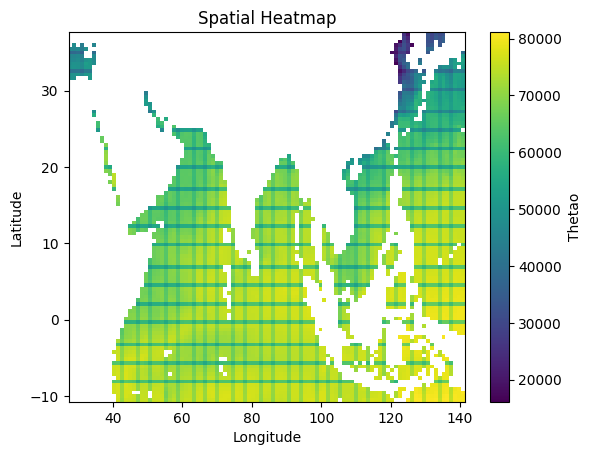

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure()
# plt.hist2d(thetao_data["longitude"], thetao_data["latitude"], weights=thetao_data["thetao"], bins=100)
# plt.colorbar(label="Thetao")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.title("Spatial Heatmap")
# plt.show()

In [5]:
#check for missing values
missing_values = thetao_data.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
depth               0
latitude            0
longitude           0
time                0
thetao       10955772
dtype: int64


In [6]:
print(10955772/24753624)

0.44259264825223166


In [16]:
# Filter out rows with just null values in 'thetao' column
thetao_null = thetao_data.loc[thetao_data["thetao"].isna()]

In [17]:
print(thetao_null.shape)

(10955772, 5)


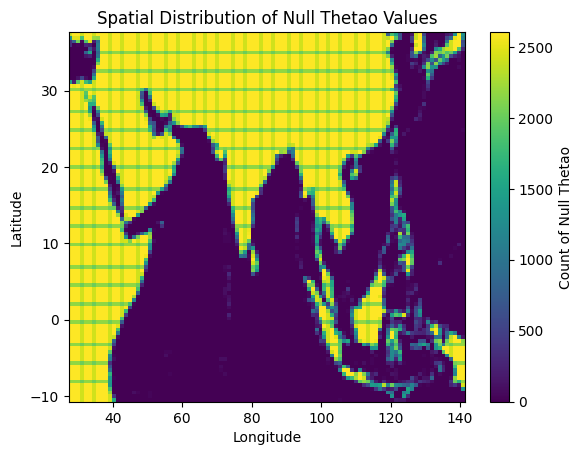

In [18]:
# Distribution of thetao_null
import matplotlib.pyplot as plt
plt.figure()
plt.hist2d(thetao_null["longitude"], thetao_null["latitude"], bins=100)
plt.colorbar(label="Count of Null Thetao")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Null Thetao Values")
plt.show()

Vậy là, khi lấy dữ liệu thetao (trong khoảng 1 tháng từ 1/1/2025 đến 31/1/2025) về theotao từ copernius có khoảng 44.25% là các giá trị null, thì các giá trị này thuộc vào đất liền. 

Nghĩa là:

1/ Có cách nào optimize lưu trữ, khi lấy dữ liệu từ copernius về lưu .nc hay không? Vì 50% lưu trong tọa độ này đều là đất liền, giá trị thetao đều null

2/ Việc khi join dữ liệu lat, long, time (trong dataset cá) từ gbif join và trả về null thetao, thì khả năng cao là bị lỗi do lệch tọa độ lat, long, và dẫn đến khi join vào thì trả về các dữ liệu môi trường đều là null